# Salary Prediction - Exploratory Data Analysis
## 1. Load the Data

In [2]:
import pandas as pd
df = pd.read_csv('../data/raw/ds_salaries.csv')
print(df.head())


   Unnamed: 0  work_year experience_level employment_type  \
0           0       2020               MI              FT   
1           1       2020               SE              FT   
2           2       2020               SE              FT   
3           3       2020               MI              FT   
4           4       2020               SE              FT   

                    job_title  salary salary_currency  salary_in_usd  \
0              Data Scientist   70000             EUR          79833   
1  Machine Learning Scientist  260000             USD         260000   
2           Big Data Engineer   85000             GBP         109024   
3        Product Data Analyst   20000             USD          20000   
4   Machine Learning Engineer  150000             USD         150000   

  employee_residence  remote_ratio company_location company_size  
0                 DE             0               DE            L  
1                 JP             0               JP            S  

## 2. Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 73.8 KB


## 3. Basic Statistics

In [4]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


## 4. Target Variable Analysis - salary_in_usd

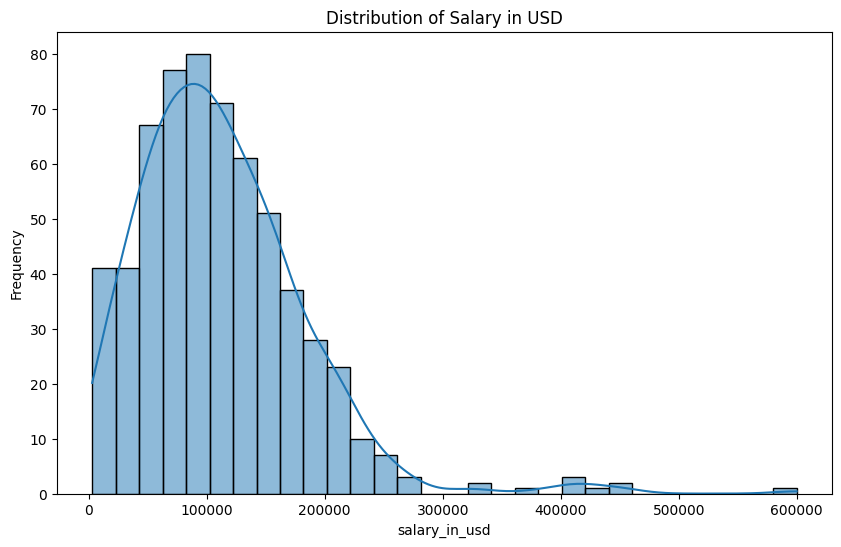

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (10, 6))
sns.histplot(df['salary_in_usd'], bins = 30, kde = True)
plt.xlabel('salary_in_usd')
plt.ylabel('Frequency')
plt.title('Distribution of Salary in USD')
plt.show()

### Boxplot - Detecting Outliers in salary_in_usd


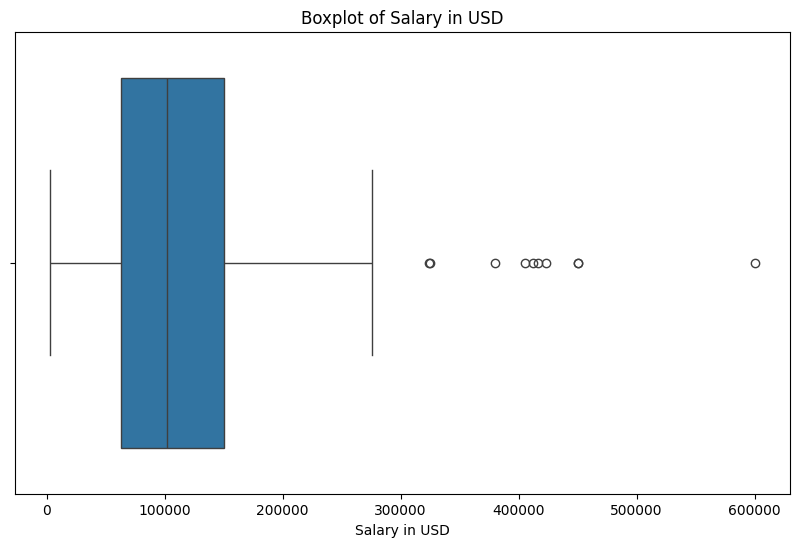

In [6]:
plt.figure(figsize = (10, 6))
sns.boxplot(x= df['salary_in_usd'])
plt.xlabel('Salary in USD')
plt.title('Boxplot of Salary in USD')
plt.show()

In [7]:
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['salary_in_usd'] < lower_bound) | (df['salary_in_usd'] > upper_bound)]
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f'Number of outliers: {outliers.shape[0]}')  

Q1: 62726.0
Q3: 150000.0
IQR: 87274.0
Lower bound: -68185.0
Upper bound: 280911.0
Number of outliers: 10


**Outlier Finding:** 10 outliers detected above $280,911 using IQR method.
Decision: Cap outliers at upper bound during preprocessing (Winsorization).

## 5. Categorical Columns Analysis
### 5.1 Experience Level Distribution

**Finding:** Dataset is imbalanced across experience levels. 
SE dominates (~275), EX underrepresented (~28). 
Model may underperform on Executive salary predictions.

### 5.2 Employment Type Distribution

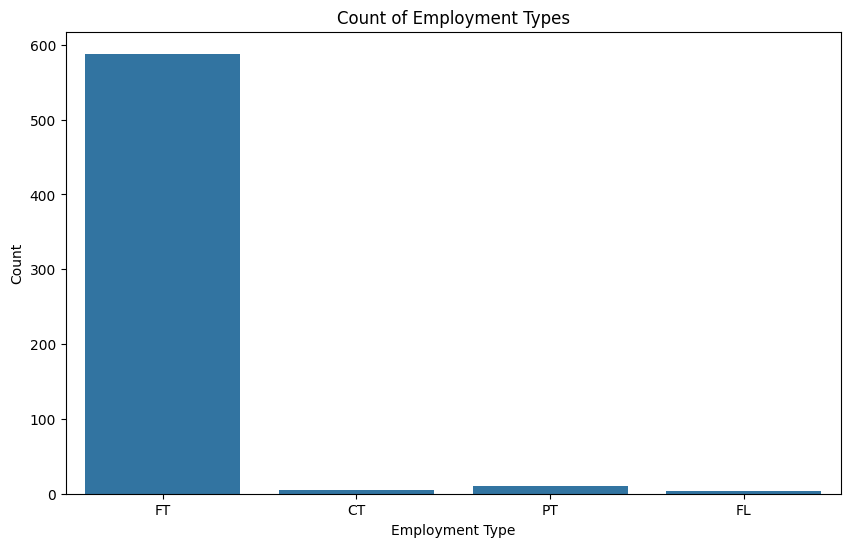

In [8]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'employment_type', data = df)
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.title('Count of Employment Types')
plt.show()

**Finding:** employment_type is extremely imbalanced — 97% Full Time.
Decision: Drop this column during preprocessing — low variance, no predictive value.

### 5.3 Company Size Distribution

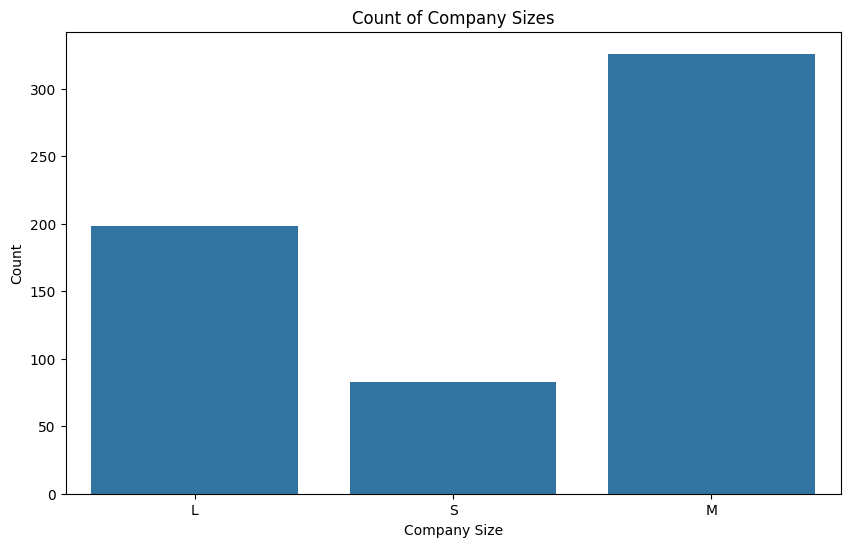

In [9]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'company_size', data = df)
plt.xlabel('Company Size')
plt.ylabel('Count')
plt.title('Count of Company Sizes')
plt.show()

**Finding:** company_size is moderately imbalanced — M dominates (~325), S underrepresented (~85).
Decision: Keep — company size has predictive value for salary. Enough representation in all categories.

### 5.3 Remote Ratio Distribution

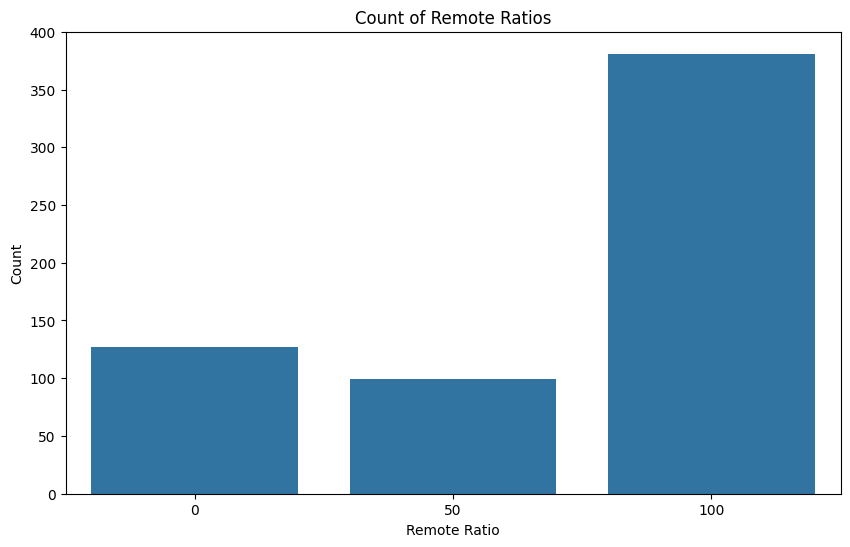

In [10]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'remote_ratio', data = df)
plt.xlabel('Remote Ratio')
plt.ylabel('Count')
plt.title('Count of Remote Ratios')
plt.show()

**Finding:** remote_ratio is imbalanced — fully remote (100) dominates (~380).
All three categories have meaningful representation — keep it.
Decision: Treat as categorical during preprocessing, not numeric.

In [11]:
print(df['job_title'].nunique())
print(df['job_title'].value_counts().head(10))

50
job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
Name: count, dtype: int64


In [12]:
print(df['job_title'].value_counts().tail(10))

job_title
3D Computer Vision Researcher     1
Marketing Data Analyst            1
Data Specialist                   1
Finance Data Analyst              1
Big Data Architect                1
Staff Data Scientist              1
Head of Machine Learning          1
NLP Engineer                      1
Lead Machine Learning Engineer    1
Data Analytics Lead               1
Name: count, dtype: int64


In [13]:
title_counts = df['job_title'].value_counts()
print('Titles with 10+ records:', (title_counts >= 10).sum())
print('Titles grouped as others:', (title_counts < 10).sum())
print("\nTitles kept: ")
print(title_counts[title_counts >= 10])

Titles with 10+ records: 7
Titles grouped as others: 43

Titles kept: 
job_title
Data Scientist               143
Data Engineer                132
Data Analyst                  97
Machine Learning Engineer     41
Research Scientist            16
Data Science Manager          12
Data Architect                11
Name: count, dtype: int64


**Finding:** 50 unique job titles — too many for direct encoding.
Decision: Keep titles with 10+ records (7 titles, 74% of data).
Group remaining 43 titles into "Other" category (rare label encoding).
Threshold: 10 records minimum.

In [14]:
print("employee_residence unique values:", df['employee_residence'].nunique())
print("company_location unique values:", df['company_location'].nunique())

employee_residence unique values: 57
company_location unique values: 50


In [15]:
print(df['employee_residence'].value_counts().head(10))
print("\n")
print(df['company_location'].value_counts().head(10))

employee_residence
US    332
GB     44
IN     30
CA     29
DE     25
FR     18
ES     15
GR     13
JP      7
PK      6
Name: count, dtype: int64


company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
NL      4
Name: count, dtype: int64


**Finding:** employee_residence (57 unique) and company_location (50 unique) are highly correlated.
US dominates both (~55% of data).
Decision: Drop employee_residence (redundant).
Engineer company_location into economic tiers: High/Middle/Low income.
This captures the economic signal without 50 noisy country categories.

## Univariate Analysis Summary — Preprocessing Decisions

**Columns to drop:**
- Unnamed: 0 — row index
- salary — redundant, using salary_in_usd
- salary_currency — redundant
- employment_type — 97% full time, no variance
- employee_residence — redundant with company_location

**Columns to engineer:**
- job_title — rare label encoding, threshold 10, group into "Other"
- company_location — map to economic tiers (High/Middle/Low)
- experience_level — ordinal encoding (EN=0, MI=1, SE=2, EX=3)
- company_size — ordinal encoding (S=0, M=1, L=2)
- remote_ratio — treat as categorical

**Outlier handling:**
- salary_in_usd — cap at upper bound $280,911 (Winsorization)

**Target variable:**
- salary_in_usd

## 6. Bivariate Analysis — Feature vs Salary

### 6.1 Experience Level vs Salary

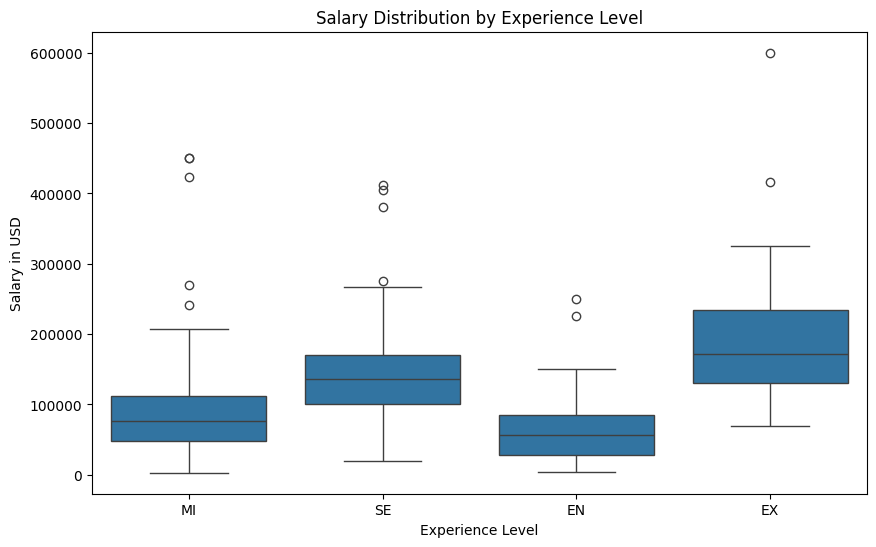

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.xlabel('Experience Level')
plt.ylabel('Salary in USD') 
plt.title('Salary Distribution by Experience Level')
plt.show()

EN (Entry):    narrow box, low median ~$55k, short whiskers → consistent, low salaries
MI (Mid):      wider box, median ~$80k, long right whisker → more variation, some high earners
SE (Senior):   wide box, median ~$135k, long whiskers → high variation, strong earners
EX (Executive): very wide box, median ~$175k, very long whiskers → highest variation


**Finding:** Strong positive relationship between experience_level and salary_in_usd.
Median salaries: EN ~$55k, MI ~$80k, SE ~$135k, EX ~$175k.
Clear monotonic pattern — excellent predictive feature.
EX shows high variance due to company size and geography differences.

### 6.2 Company Size vs Salary

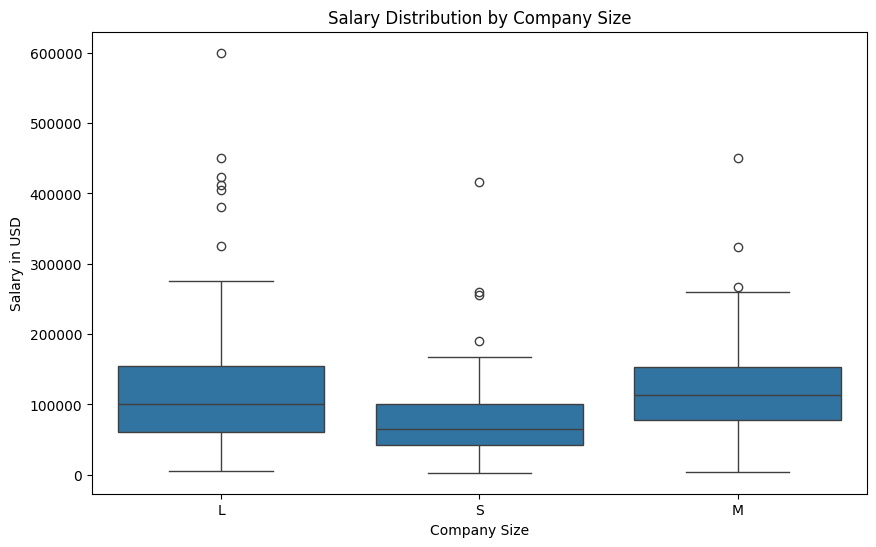

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='company_size', y='salary_in_usd', data=df)
plt.xlabel('Company Size')
plt.ylabel('Salary in USD') 
plt.title('Salary Distribution by Company Size')
plt.show()

**Finding:** company_size shows weak salary differentiation.
L and M companies have nearly identical medians (~$110k).
S companies pay noticeably less (~$70k median).
Weaker predictive power than experience_level but still worth keeping.

### 6.3 Job Title vs Salary

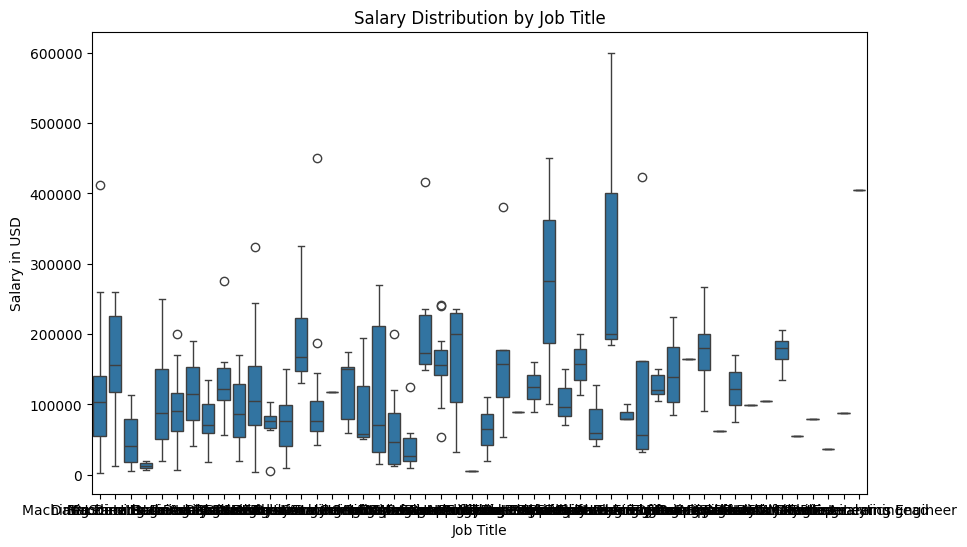

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='job_title', y='salary_in_usd', data=df)
plt.xlabel('Job Title')
plt.ylabel('Salary in USD') 
plt.title('Salary Distribution by Job Title')
plt.show()

In [ ]:
top_titles = df['job_title'].value_counts().index[:7]
df['job_title'].isin(top_titles)
df['job_title_grouped'] = df['job_title'].where(df['job_title'].isin(top_titles), other='Other')
print(df['job_title_grouped'].value_counts())

# Method 2: Using np.where
import numpy as np
df['job_title_grouped'] = np.where(df['job_title'].isin(top_titles), df['job_title'], 'Other')

# Method 3: Using .apply 
df['job_title_grouped'] = df['job_title'].apply(lambda x: x if x in top_titles else 'Other')

# Method 4: using .map with a dictionary
title_mapping = {title: title for title in top_titles}
df['job_title_grouped'] = df['job_title'].map(title_mapping).fillna('Other')

job_title_grouped
Other                        155
Data Scientist               143
Data Engineer                132
Data Analyst                  97
Machine Learning Engineer     41
Research Scientist            16
Data Science Manager          12
Data Architect                11
Name: count, dtype: int64


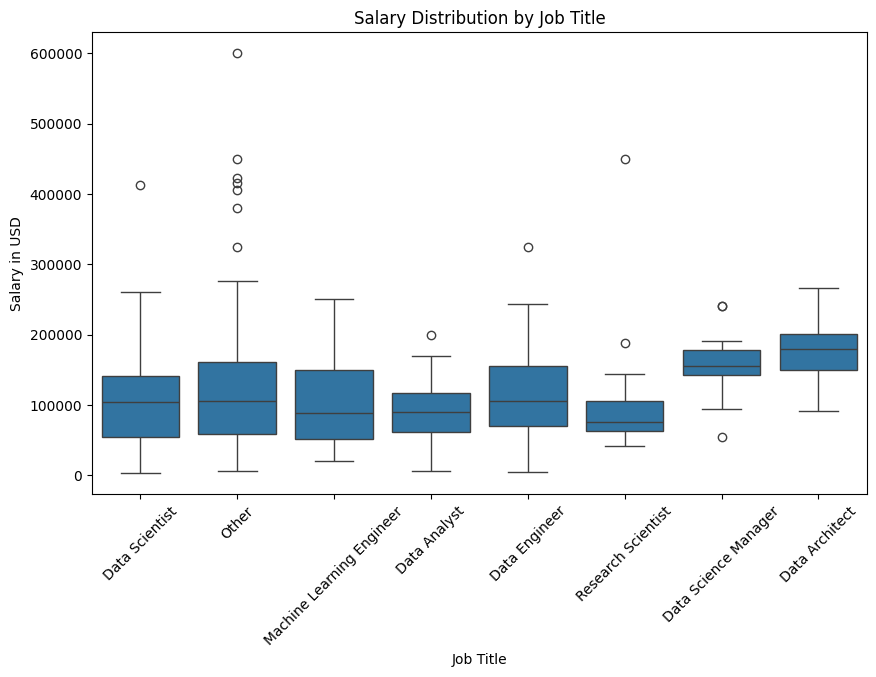

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='job_title_grouped', y='salary_in_usd', data=df)
plt.xlabel('Job Title')
plt.ylabel('Salary in USD') 
plt.xticks(rotation=45)
plt.title('Salary Distribution by Job Title')
plt.show()

**Finding:** job_title shows moderate predictive power.
Data Architect (~$180k) and Data Science Manager (~$165k) are highest paid.
Most other titles cluster around $100-115k median.
"Other" group shows high variance as expected from mixed titles.

### 6.4 Work Year vs Salary

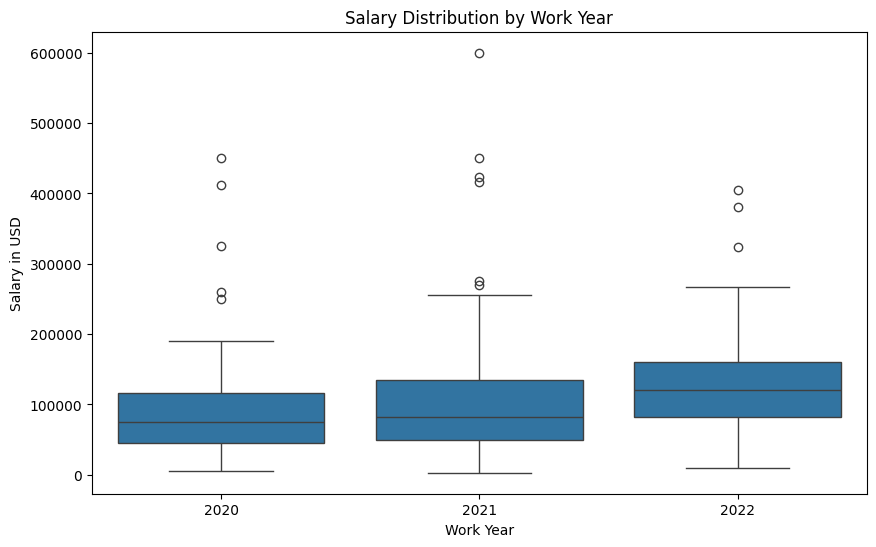

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='work_year', y='salary_in_usd', data=df)
plt.xlabel('Work Year')
plt.ylabel('Salary in USD') 
plt.title('Salary Distribution by Work Year')
plt.show()

**Finding:** Salaries increased over time — notable jump in 2022.
2020 and 2021 medians similar (~$80k), 2022 jumped to ~$120k.
work_year has moderate predictive value — keep it.

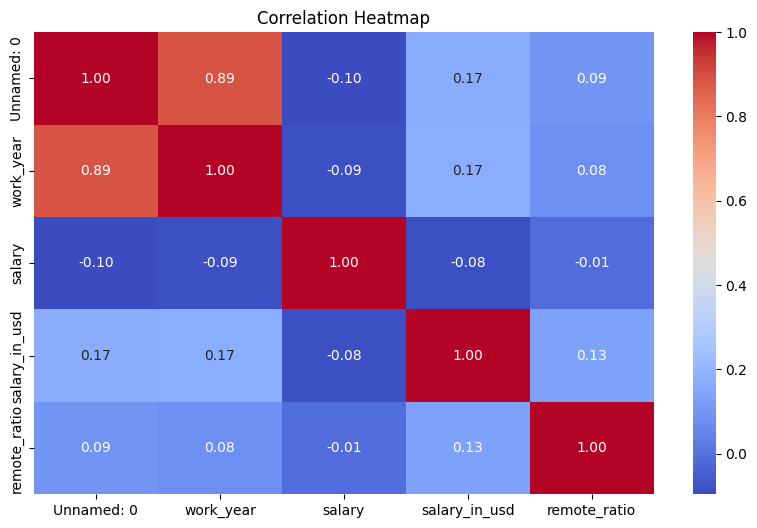

In [25]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Finding:** Correlation heatmap shows weak linear relationships between numeric features and salary_in_usd.
work_year (0.17) and remote_ratio (0.13) have weak positive correlation with salary.
Unnamed: 0 vs work_year (0.89) is spurious — confirms dropping Unnamed: 0.
Non-linear relationships likely exist — Decision Tree is appropriate choice.

## 7. EDA Summary — Key Findings & Preprocessing Plan

### Dataset Overview
- 607 rows, 12 columns
- No missing values
- Target variable: salary_in_usd

### Columns to Drop
- Unnamed: 0 — row index, no value
- salary — redundant
- salary_currency — redundant  
- employment_type — 97% full time, no variance
- employee_residence — redundant with company_location

### Columns to Engineer
- job_title — rare label encoding (threshold 10, group into Other)
- company_location — map to economic tiers (High/Middle/Low)
- experience_level — ordinal encoding (EN=0, MI=1, SE=2, EX=3)
- company_size — ordinal encoding (S=0, M=1, L=2)
- remote_ratio — treat as categorical

### Outlier Handling
- salary_in_usd — cap at $280,911 (Winsorization)

### Feature Importance (from bivariate analysis)
- experience_level — strongest predictor
- job_title — moderate predictor
- work_year — moderate predictor
- company_size — weak predictor
- remote_ratio — weak predictor